Contenido bajo licencia Creative Commons BY 4.0 y código bajo licencia MIT. © Nicolás Guarín-Zapata 2026.

# Elementos finitos en 1D

Queremos resolver al ecuación de Poisson en 1D usando
el método de elementos finitos.

$$-\frac{d^2 u}{dx^2} = f(x)\, ,$$

con $u(0) = u(1)  = 0$.

Vamos a usar una solución aproximada de la forma

$$u(x) = \sum_{n=0}^{N} u_n \phi_n(x)\, ,$$

Si usamos el método de Galerkin, la ecuación diferencial es equivalente
al siguiente problema

$$\int_{0}^{1} \frac{d u}{d x} \frac{d \phi_n}{d x} dx
= \int_{0}^{1}  \phi_n f(x) dx\, \quad \forall \phi_n\, .$$

Si remplazamos $u(x)$ en este sistema obtenemos

$$\sum_{j=0}^N \left[\int_{0}^{1} \frac{d \phi_i}{d x} \frac{d \phi_j}{d x} dx\right] u_j
= \int_{0}^{1}  \phi_j f(x) dx\, \quad \forall \phi_j\, .$$

Esto lleva al siguiente sistema de ecuaciones

$$[K]\{\mathbf{u}\} = \{\mathbf{b}\}\, .$$

<div class="alert alert-info">

En este notebook vamos a calcular las matrices de forma simbólica.
Este es un cálculo muy ineficiente pero nos permite realizar de forma
automática los cálculos que discutimos en clase.

</div>



In [1]:
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [2]:
%matplotlib widget

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import *

In [4]:
init_printing()

# Configuracion graficos
gris = '#757575'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["text.color"] = gris
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.color"] = gris
plt.rcParams["ytick.color"] = gris
plt.rcParams["axes.labelcolor"] = gris
plt.rcParams["axes.edgecolor"] = gris
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

In [5]:
x = symbols('x')

In [6]:
def plot_expr(expr, x, rango=(0, 1), ax=None, linestyle="solid"):
    """Grafica expresiones de SymPy que dependen de una variable"""
    expr_num = lambdify(x, expr, "numpy")
    x0 = rango[0]
    x1 = rango[1]
    x_num = np.linspace(x0, x1, 301)
    if ax is None:
        plt.figure()
        ax = plt.gca()
    ax.plot(x_num, expr_num(x_num), linestyle=linestyle)

In [7]:
def hat_fun(x, xi, h):
    """Función sombrero centrada en xi y de semi-ancho h."""
    fun = Piecewise((0, x< xi - h),
              ((x - xi)/h + 1, (xi - h <= x) & (x < xi)),
              (1 - (x - xi)/h, (xi <= x) & (x < xi + h)),
              (0, x>= xi + h))
    return fun

Podemos graficar la función sombrero centrada en 3 y de semi-ancho 1.

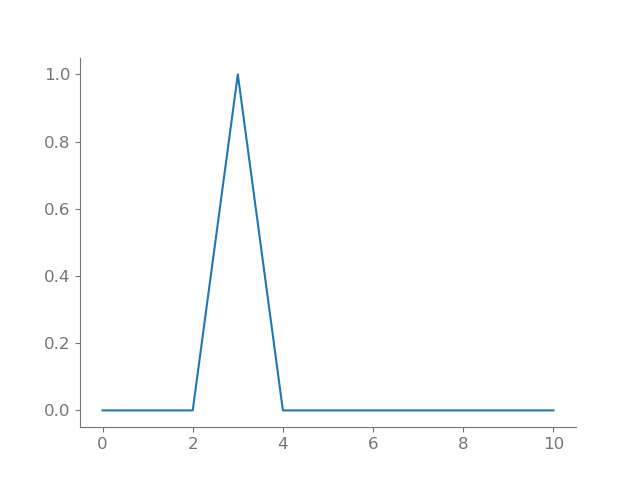

In [8]:
plt.figure()
ax = plt.gca()
plot_expr(hat_fun(x, 3, 1), x, (0, 10), ax=ax);

Ahora, vamos a partir el intervalo $(0, 1)$ en 20 sub-intervalos.

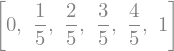

In [9]:
a = 0
b = 1
n = 5
dx = S(b - a)/n
coords = [a + dx*cont for cont in range(n + 1)]
coords

Queremos tener una función sombrero asociada cada punto.

In [10]:
basis = [hat_fun(x, coord, dx) for coord in coords[1:-1]]
H = Matrix(basis)

In [11]:
basis_diff = [fun.diff(x) for fun in basis]
D = Matrix(basis_diff)

Probemos la implementación con la función $f(x) = 20 x^3$, que lleva a
la solución

$$u(x) = - x (x^4 - 1)$$

In [12]:
f = 20*x**3
b = (f * H).integrate((x, 0, 1))

In [13]:
K = (D * D.T).integrate((x, 0, 1))

In [14]:
u = linsolve((K, b))

In [15]:
u_sol = Matrix(list(u)[0]).dot(basis)

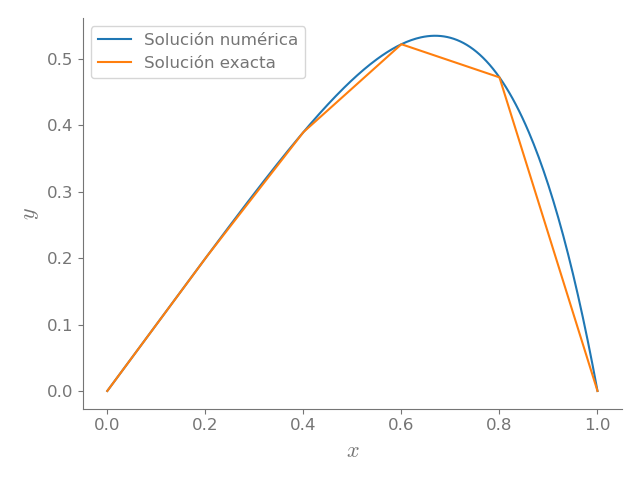

In [17]:
plt.figure()
ax = plt.gca()
plot_expr(-x*(x**4 - 1), x, (0, 1), ax=ax)
plot_expr(u_sol, x, (0, 1), ax=ax)
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel(r"$y$", fontsize=16)
plt.legend(["Solución exacta", "Solución numérica"])
plt.tight_layout()
plt.show();